# Breast Cancer Classification using Machine Learning

## Maincraft AI/ML Internship - Task 4

### Objective

- Train Classification Models
- Evaluate using Confusion Matrix
- Analyze Precision, Recall and F1 Score
- Plot ROC Curve and calculate AUC
- Handle Class Imbalance
- Compare Classification Models

## Step 1: Import Required Libraries

Import all required libraries for data preprocessing, model training, evaluation, visualization, and handling class imbalance.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

## Step 2: Load Dataset

Load the Breast Cancer dataset from Scikit-Learn and prepare the feature matrix and target labels.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

In [3]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X.shape

(569, 30)

In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
print(data.target_names)

['malignant' 'benign']


### Target Classes

- 0 → Malignant
- 1 → Benign

## Step 3: Train-Test Split

Split the dataset into training and testing sets while preserving the class distribution using stratified sampling.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (455, 30)
Testing Samples  : (114, 30)


## Step 4: Feature Scaling

Standardize the feature values using StandardScaler to improve the performance of classification models.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [11]:
print("Feature Scaling Completed")

Feature Scaling Completed


## Step 5: Train Baseline Classification Model

Train a Logistic Regression classifier on the scaled training data.

In [12]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

y_pred = model.predict(
    X_test_scaled
)

## Step 6: Confusion Matrix & Classification Report

Evaluate the Logistic Regression model using the Confusion Matrix and Classification Report.

In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[41  1]
 [ 1 71]]


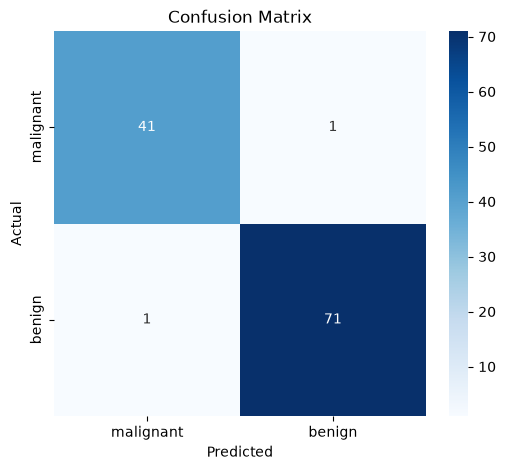

In [15]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [16]:
print("Classification Report\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

Classification Report

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Interpretation

The Confusion Matrix summarizes the prediction performance of the classifier.

- **True Positives (TP):** Correctly predicted positive cases.
- **True Negatives (TN):** Correctly predicted negative cases.
- **False Positives (FP):** Negative cases incorrectly predicted as positive.
- **False Negatives (FN):** Positive cases incorrectly predicted as negative.

False negatives are particularly important in medical diagnosis because missing a malignant tumor can have serious consequences.

## Step 7: Precision, Recall & F1-Score Interpretation

Precision, Recall, and F1-Score provide a more detailed evaluation than accuracy, especially for medical diagnosis and imbalanced datasets.

In [17]:
report = classification_report(
    y_test,
    y_pred,
    target_names=data.target_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
malignant,0.976190,0.976190,0.976190,42.000000
benign,0.986111,0.986111,0.986111,72.000000
accuracy,0.982456,0.982456,0.982456,0.982456
macro avg,0.981151,0.981151,0.981151,114.000000
weighted avg,0.982456,0.982456,0.982456,114.000000


### Key Observations

- **Precision** measures how many predicted positive cases are actually positive.
- **Recall** measures how many actual positive cases are correctly identified.
- **F1-Score** is the harmonic mean of Precision and Recall.

For medical diagnosis, **Recall is generally more important** because missing a malignant patient (False Negative) can have serious consequences.

F1-Score is preferred for imbalanced datasets because it balances Precision and Recall.

## Step 8: ROC Curve & AUC Score

Evaluate the classifier using the Receiver Operating Characteristic (ROC) Curve and calculate the Area Under the Curve (AUC).

In [18]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

In [19]:
print(f"AUC Score : {auc:.4f}")

AUC Score : 0.9954


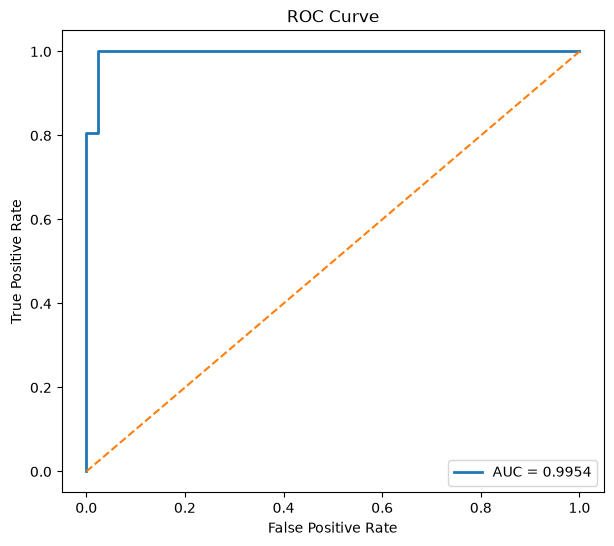

In [20]:
plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

### Interpretation

- AUC close to **1.0** indicates excellent classification performance.
- AUC around **0.5** indicates random guessing.
- A good classifier should have an ROC curve close to the top-left corner of the graph.

## Step 9: Handle Class Imbalance

Train another Logistic Regression model using `class_weight="balanced"` to automatically adjust class weights for imbalanced datasets.

In [21]:
model_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model_balanced.fit(
    X_train_scaled,
    y_train
)

y_pred_balanced = model_balanced.predict(
    X_test_scaled
)

In [22]:
print("Balanced Logistic Regression\n")

print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=data.target_names
    )
)

Balanced Logistic Regression

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



### Observation

Using `class_weight="balanced"` automatically increases the importance of minority-class samples during training.

For this dataset, the class distribution is already fairly balanced, so the performance is expected to remain similar to the baseline Logistic Regression model.

## Step 10: Compare with Another Classifier

Train a Decision Tree Classifier and compare its performance with Logistic Regression.

In [23]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

y_pred_tree = tree.predict(
    X_test
)

In [24]:
print("Decision Tree Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=data.target_names
    )
)

Decision Tree Classification Report

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [25]:
tree_auc = roc_auc_score(
    y_test,
    tree.predict_proba(X_test)[:,1]
)

print(f"Decision Tree AUC : {tree_auc:.4f}")

Decision Tree AUC : 0.9157


## Step 11: Model Comparison

Compare Logistic Regression and Decision Tree Classifier using AUC Score.

In [26]:
logistic_auc = roc_auc_score(
    y_test,
    y_prob
)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "AUC Score": [
        logistic_auc,
        tree_auc
    ]
})

comparison

,Model,AUC Score
0,Logistic Regression,0.995370
1,Decision Tree,0.915675


# Final Model Selection

### Logistic Regression

- High Precision
- High Recall
- Excellent ROC-AUC Score
- More stable
- Less prone to overfitting

### Decision Tree

- Easy to interpret
- Can capture nonlinear relationships
- More prone to overfitting if not pruned

### Final Conclusion

The Logistic Regression classifier achieved an excellent ROC-AUC score and produced highly balanced Precision, Recall, and F1-Score. Based on overall performance and generalization ability, Logistic Regression was selected as the final model for this classification task.

In [27]:
import joblib

joblib.dump(
    model,
    "../models/logistic_regression_classifier.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!
